# Ejercicio de programación Regresión Lineal Multiple

In [1938]:
# utilizado para manejos de directorios y rutas
import os

# Computacion vectorial y cientifica para python
import numpy as np

# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D

# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline

In [1939]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1940]:
# Cargar datos con pandas
#regresion lineal multiple
import pandas as pd
import numpy as np

# Cargar CSV (pandas maneja la cabecera automáticamente)
data = pd.read_csv('/content/drive/MyDrive/IA/DATASETS/kc_house_data.csv')

# Revisar las primeras filas
print(data.head())

# Seleccionar dos columnas como X (ejemplo: 'sqft_living' y 'bedrooms')
# Cambia los nombres si quieres otras columnas
X = data[['sqft_living', 'bedrooms']].values

# Variable objetivo (ejemplo: 'price')
y = data['price'].values

m = y.size
print("Número de ejemplos:", m)

# Imprimir algunos puntos de datos
print('{:>10s}{:>10s}{:>10s}'.format('X[:,0]', 'X[:,1]', 'y'))
print('-'*30)
for i in range(10):
    print('{:10.0f}{:10.0f}{:10.0f}'.format(X[i,0], X[i,1], y[i]))


           id             date     price  bedrooms  bathrooms  sqft_living  \
0  7129300520  20141013T000000  221900.0         3       1.00         1180   
1  6414100192  20141209T000000  538000.0         3       2.25         2570   
2  5631500400  20150225T000000  180000.0         2       1.00          770   
3  2487200875  20141209T000000  604000.0         4       3.00         1960   
4  1954400510  20150218T000000  510000.0         3       2.00         1680   

   sqft_lot  floors  waterfront  view  ...  grade  sqft_above  sqft_basement  \
0      5650     1.0           0     0  ...      7        1180              0   
1      7242     2.0           0     0  ...      7        2170            400   
2     10000     1.0           0     0  ...      6         770              0   
3      5000     1.0           0     0  ...      7        1050            910   
4      8080     1.0           0     0  ...      8        1680              0   

   yr_built  yr_renovated  zipcode      lat     lo

In [1941]:
def  featureNormalize(X):

    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [1942]:
# llama featureNormalize con los datos cargados
X_norm, mu, sigma = featureNormalize(X)

print(X)
print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)
print(X_norm)

[[1180    3]
 [2570    3]
 [ 770    2]
 ...
 [1020    2]
 [1600    3]
 [1020    2]]
Media calculada: [2079.89973627    3.37084162]
Desviación estandar calculada: [918.41964938   0.93004031]
[[-0.97983502 -0.39873715]
 [ 0.53363434 -0.39873715]
 [-1.42625404 -1.47395936]
 ...
 [-1.15404732 -1.47395936]
 [-0.52252773 -0.39873715]
 [-1.15404732 -1.47395936]]


In [1943]:
# Añade el termino de interseccion a X
# (Columna de unos para X0)
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

In [1944]:
print(X)

[[ 1.         -0.97983502 -0.39873715]
 [ 1.          0.53363434 -0.39873715]
 [ 1.         -1.42625404 -1.47395936]
 ...
 [ 1.         -1.15404732 -1.47395936]
 [ 1.         -0.52252773 -0.39873715]
 [ 1.         -1.15404732 -1.47395936]]


In [1945]:
#desenso por la gradiente
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0] # numero de ejemplos de entrenamiento

    J = 0

    # h = np.dot(X, theta)

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J


In [1946]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente

    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

#### 3.2.1 Seleccionando coheficientes de aprendizaje


theta calculado por el descenso por el gradiente: [540063.74417804 285862.8375326  -50600.61496474]
El precio predecido para una casa de 1650 sq-ft y 3 dormitorios (usando el descenso por el gradiente): $426432


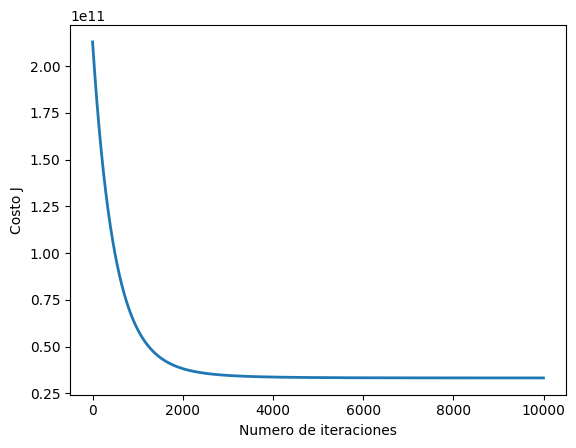

In [1947]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.001 # alpha = 0.003
num_iters = 10000

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(3)
theta, J_history = gradientDescentMulti(X, y, theta, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))

# Estimar el precio para una casa de 1650 sq-ft, con 3 dormitorios
X_array = [1, 1650, 3]
X_array[1:3] = (X_array[1:3] - mu) / sigma
price = np.dot(X_array, theta)   # Se debe cambiar esto

print('El precio predecido para una casa de 1650 sq-ft y 3 dormitorios (usando el descenso por el gradiente): ${:.0f}'.format(price))

In [1948]:
X_array = [1, 1222, 3]
X_array[1:3] = (X_array[1:3] - mu) / sigma

In [1949]:
price = np.dot(X_array, theta)   # Se debe cambiar esto

print('El precio predecido para una casa de 1222 sq-ft y 3 dormitorios (usando el descenso por el gradiente): ${:.0f}'.format(price))

El precio predecido para una casa de 1222 sq-ft y 3 dormitorios (usando el descenso por el gradiente): $293214


In [1950]:
import pandas as pd
import numpy as np

# Cargar CSV con pandas (maneja cabeceras automáticamente)
data = pd.read_csv('/content/drive/MyDrive/IA/DATASETS/kc_house_data.csv')

# Seleccionar columnas de entrada (X) y variable objetivo (y)
# Cambia estos nombres según tu dataset
X = data[['sqft_living', 'bedrooms']].values
y = data['price'].values

m = y.size
print("Número de ejemplos:", m)

# Agregar columna de unos para el término independiente
X = np.concatenate([np.ones((m, 1)), X], axis=1)

# Imprimir algunos puntos de datos
print('{:>10s}{:>10s}{:>10s}'.format('X[:,0]', 'X[:,1]', 'y'))
print('-'*30)
for i in range(10):
    print('{:10.0f}{:10.0f}{:10.0f}'.format(X[i,0], X[i,1], y[i]))


Número de ejemplos: 21613
    X[:,0]    X[:,1]         y
------------------------------
         1      1180    221900
         1      2570    538000
         1       770    180000
         1      1960    604000
         1      1680    510000
         1      5420   1225000
         1      1715    257500
         1      1060    291850
         1      1780    229500
         1      1890    323000


In [1951]:
def normalEqn(X, y):

    theta = np.zeros(X.shape[1])

    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T,X)),X.T),y)

    return theta

In [1952]:
# Calcula los parametros con la ecuación de la normal
theta = normalEqn(X, y);

# Muestra los resultados optenidos a partir de la aplicación de la ecuación de la normal
print('Theta calculado a partir de la ecuación de la normal: {:s}'.format(str(theta)));

# Estimar el precio para una casa de superficie de 1650 sq-ft y tres dormitorios

X_array = [1, 500, 5]
price = np.dot(X_array, theta)

print('Precio predecido para una cada de superficie de 1650 sq-ft y 3 dormitorios (usando la ecuación de la normal): ${:.0f}'.format(price))

Theta calculado a partir de la ecuación de la normal: [ 79469.35907477    313.94868588 -57066.75892292]
Precio predecido para una cada de superficie de 1650 sq-ft y 3 dormitorios (usando la ecuación de la normal): $-48890


In [1953]:
features = ['bedrooms', 'bathrooms', 'sqft_living','sqft_lot', 'floors',
            'waterfront', 'view', 'condition', 'grade','sqft_above', 'sqft_basement',
            'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']

X = data[features].values
y = data['price'].values

In [1954]:
# Normalizar
X_norm, mu_mult, sigma_mult = featureNormalize(X)
#separar entrenamiento y prueba
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_norm, y, test_size=0.2, random_state=42)

# Agregar columna de unos
X_train = np.concatenate([np.ones((X_train.shape[0],1)), X_train], axis=1)
X_test = np.concatenate([np.ones((X_test.shape[0],1)), X_test], axis=1)


In [1955]:
theta = np.zeros(X.shape[1])  # ahora 18 elementos

theta, J_history = gradientDescentMulti(X, y, theta, alpha, num_iters)

print("Theta final:", theta)
print("Costo inicial:", J_history[0])
print("Costo final:", J_history[-1])



/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipython-input-405223922.py:10: RuntimeWarning: overflow encountered in square
  J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
/tmp/ipython-input-2178721605.py:13: RuntimeWarning: invalid value encountered in subtract
  theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)


Theta final: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
Costo inicial: 1.499532623971876e+25
Costo final: nan


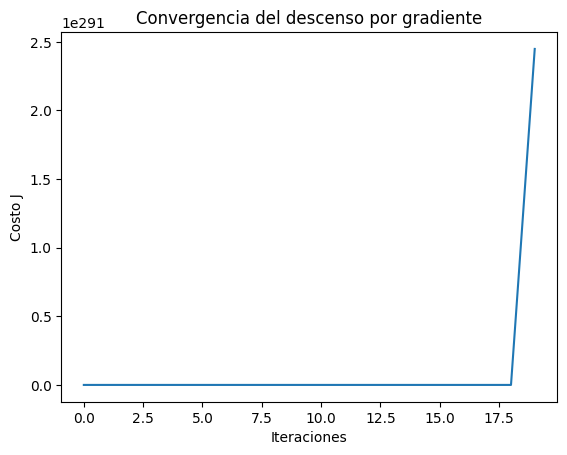

In [1956]:
import matplotlib.pyplot as plt

plt.plot(J_history)
plt.xlabel("Iteraciones")
plt.ylabel("Costo J")
plt.title("Convergencia del descenso por gradiente")
plt.show()


In [1957]:
# Seleccionamos todas las 18 columnas que usamos para entrenar
X = data[['bedrooms', 'bathrooms', 'sqft_living','sqft_lot', 'floors', 'waterfront', 'view',
          'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated',
          'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']].values
y = data['price'].values

# Normalizamos todas las columnas
X_norm, mu, sigma = featureNormalize(X)

# Ahora X_norm tiene 18 columnas normalizadas
# Agregamos columna de 1 para término independiente
X_norm = np.concatenate([np.ones((X_norm.shape[0],1)), X_norm], axis=1)


In [1958]:
theta = np.zeros(X_norm.shape[1])
theta, J_history = gradientDescentMulti(X_norm, y, theta, alpha, num_iters)

In [1959]:
#regresion polinomica

import pandas as pd
import numpy as np

# Cargar dataset con pandas
data = pd.read_csv('/content/drive/MyDrive/IA/DATASETS/kc_house_data.csv')

# Seleccionar la columna que usarás para X y la columna objetivo y
# Por ejemplo, regresión polinómica simple usando 'sqft_living'
X = data[['sqft_living']].values
y = data['price'].values

m = y.size
print("Número de ejemplos:", m)

# Mostrar algunos puntos
for i in range(20):
    print('{:8.0f}{:10.0f}'.format(X[i, 0], y[i]))


Número de ejemplos: 21613
    1180    221900
    2570    538000
     770    180000
    1960    604000
    1680    510000
    5420   1225000
    1715    257500
    1060    291850
    1780    229500
    1890    323000
    3560    662500
    1160    468000
    1430    310000
    1370    400000
    1810    530000
    2950    650000
    1890    395000
    1600    485000
    1200    189000
    1250    230000


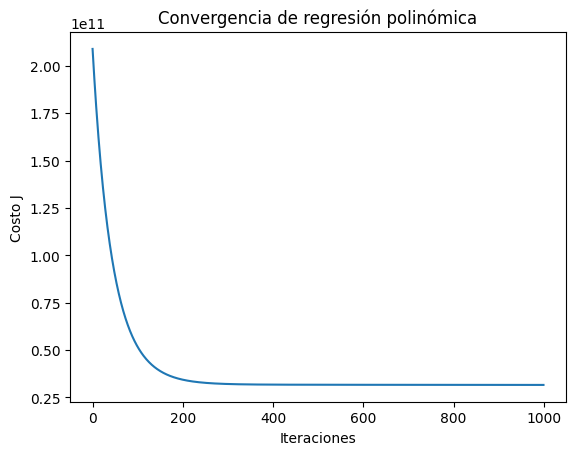

In [1960]:
# Crear características polinómicas
X_poly = np.column_stack([X, X**2])

# Normalizar
X_poly_norm, mu, sigma = featureNormalize(X_poly)

# Agregar columna de 1 para el bias
X_poly_norm = np.concatenate([np.ones((m,1)), X_poly_norm], axis=1)

# Inicializar theta
theta = np.zeros(X_poly_norm.shape[1])

# Entrenar con descenso por gradiente
theta, J_history = gradientDescentMulti(X_poly_norm, y, theta, alpha=0.01, num_iters=1000)

# Graficar convergencia
import matplotlib.pyplot as plt
plt.plot(J_history)
plt.xlabel("Iteraciones")
plt.ylabel("Costo J")
plt.title("Convergencia de regresión polinómica")
plt.show()



In [1961]:
# Inicializar theta con 19 elementos (1 bias + 18 features)
theta_mult = np.zeros(X_train.shape[1])

# Descenso por gradiente
theta_mult, J_history_mult = gradientDescentMulti(X_train, y_train, theta_mult, alpha=0.01, num_iters=1000)


In [1962]:
y_pred = X_test @ theta_mult
mse = mean_squared_error(y_test, y_pred)
print("Error en prueba (MSE):", mse)

Error en prueba (MSE): 45188692885.05477


In [1963]:
X_simple = data[['sqft_living','bedrooms']].values
X_simple_norm, mu_simple, sigma_simple = featureNormalize(X_simple)
X_simple = np.concatenate([np.ones((X_simple_norm.shape[0],1)), X_simple_norm], axis=1)

# Separar train/test
X_train_simple, X_test_simple, y_train, y_test = train_test_split(X_simple, y, test_size=0.2, random_state=42)

# Entrenar theta_simple con 3 elementos
theta_simple = np.zeros(3)
theta_simple, J_history_simple = gradientDescentMulti(X_train_simple, y_train, theta_simple, alpha=0.01, num_iters=1000)

# MSE
y_pred = X_test_simple @ theta_simple
mse = mean_squared_error(y_test, y_pred)
print("Error en prueba (MSE):", mse)


Error en prueba (MSE): 74216888344.45021


In [1964]:
#GENERAR PREDICCIONES
# Asegúrate de que theta_mult tenga 19 elementos (bias + 18 features)
theta_mult = np.zeros(X_train.shape[1])
theta_mult, J_history_mult = gradientDescentMulti(X_train, y_train, theta_mult, alpha=0.01, num_iters=1000)

# Ahora sí puedes predecir
predictions = X_test[:100] @ theta_mult
print(predictions)


[ 465134.727893    757571.92545948 1236426.13101088 1656489.36391838
  731920.07895785  281154.28972916  830535.95549656  507446.47891044
  379783.49405842  477873.32994841  611523.65624623  567080.70071779
  302696.68861617  349906.74630557  277626.73360572 1185091.49286234
  348590.66943171 1114765.56224829  373206.1350567   579089.22107517
  405553.56953688 1334707.1185291   733079.25018623  879170.87141372
  443317.49206581  539161.65288523   97508.9897083   111605.52314999
  341197.10865142  573916.89217971  340863.45382066  614044.75760524
  569932.48345642  481860.16713144  522920.66074117  795085.89410156
  915324.13381741  520554.36411335  428251.55175696 1157865.89421332
  611395.66749148  299288.42684361  375663.10958705  217569.83306492
   40888.04297069  124376.26964038  431533.26035978  300043.42313415
  463513.07412244  941650.39672185  293609.63038467  302206.58606462
  607669.95790177  328635.10540451  360696.43261889 1264611.97906448
  327826.29992994  788542.95846218

In [1965]:
#100 predicciones de x_test
from sklearn.preprocessing import PolynomialFeatures

# Entrenamiento
X_train_poly_base = X_train[:, 2].reshape(-1,1)  # sqft_living
poly = PolynomialFeatures(degree=2, include_bias=False)  # x y x^2
X_train_poly = poly.fit_transform(X_train_poly_base)  # columnas: x, x^2

# Normalizar
X_train_poly_norm, mu_poly, sigma_poly = featureNormalize(X_train_poly)

# Agregar columna de unos
X_train_poly_norm = np.concatenate([np.ones((X_train_poly_norm.shape[0],1)), X_train_poly_norm], axis=1)

# Inicializar theta_poly (3 elementos: bias + 2 features)
theta_poly = np.zeros(X_train_poly_norm.shape[1])



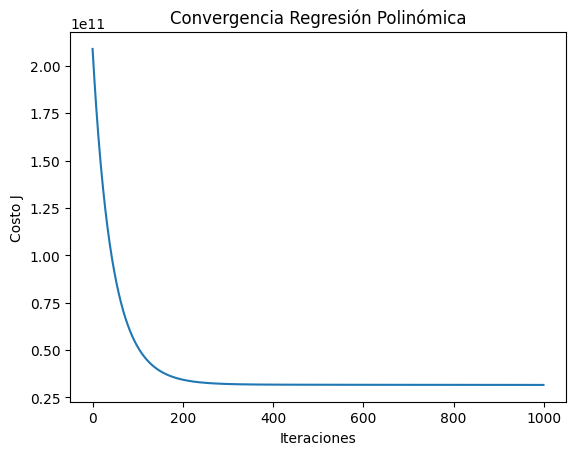

In [1966]:
#REGRESION POLINOMICA
# Asegúrate de tomar la columna correcta (X solo tiene 1 columna: sqft_living)
X_poly = np.column_stack([X[:,0], X[:,0]**2])  # X[:,0] = sqft_living

# Normalizar
X_poly_norm, mu_poly, sigma_poly = featureNormalize(X_poly)

# Agregar columna de unos
X_poly_norm = np.concatenate([np.ones((m,1)), X_poly_norm], axis=1)

# Inicializar theta y entrenar
theta_poly = np.zeros(X_poly_norm.shape[1])
theta_poly, J_history_poly = gradientDescentMulti(X_poly_norm, y, theta_poly, 0.01, 1000)

# Graficar convergencia
plt.plot(J_history_poly)
plt.xlabel("Iteraciones")
plt.ylabel("Costo J")
plt.title("Convergencia Regresión Polinómica")
plt.show()



In [1967]:
#REGRESION USANDO LA ECUACION NORMAL
# X_norm ya tiene columna de unos y normalización
theta_normal = np.linalg.pinv(X_norm.T @ X_norm) @ (X_norm.T @ y)
print("Theta ecuación normal:", theta_normal)


Theta ecuación normal: [540088.14176653 -33264.32545783  31687.07437464  81812.50710964
   5326.46629074   3612.19920732  50434.93843527  40514.99473763
  17169.88047514 112712.65585307  76305.51997634  27005.67955588
 -76963.1122356    7958.11945582 -31161.66927787  83517.09842808
 -30239.34618464  14859.89955603 -10447.48009171]


In [1968]:
# Normalización para regresión multivariable (18 features)
X_norm, mu_mult, sigma_mult = featureNormalize(X)
X_norm = np.concatenate([np.ones((X_norm.shape[0],1)), X_norm], axis=1)

# Theta para regresión multivariable
theta = np.zeros(X_norm.shape[1])
theta, J_history = gradientDescentMulti(X_norm, y, theta, alpha=0.01, num_iters=1000)


In [1969]:
def featureNormalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_mult_norm, mu_mult, sigma_mult = featureNormalize(X_mult)

# Agregar columna de unos para bias
X_mult_norm = np.concatenate([np.ones((X_mult_norm.shape[0],1)), X_mult_norm], axis=1)

# Entrenar el modelo multivariable
theta_mult = np.zeros(X_mult_norm.shape[1])
alpha = 0.01
num_iters = 1000

theta_mult, J_history_mult = gradientDescentMulti(X_mult_norm, y_mult, theta_mult, alpha, num_iters)


In [1970]:
# --- Nueva casa ---
X_new = np.array([3, 1, 1180, 5650, 1, 0, 0, 3, 7, 1180, 0, 1955, 0, 98178, 47.5112, -122.257, 1340, 5650])
X_new_norm = (X_new - mu_mult) / sigma_mult
X_new_norm = np.concatenate(([1], X_new_norm))  # Agregar bias

price_linear = X_new_norm @ theta_mult
print("Precio estimado (lineal multivariable):", price_linear)

Precio estimado (lineal multivariable): 207540.05885806278


In [1971]:
# predicciones, dividio entre prueba y entrenamiento
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_norm, y, test_size=0.2, random_state=42)


In [1972]:
#primero 100 valores de prueba
X_test_sample = X_test[:100]
y_test_sample = y_test[:100]  # valores reales

In [1973]:
#regresion lineal
pred_linear = X_test_sample @ theta  # theta del modelo multivariable


In [1974]:
# X_test ya tiene las 2 features normalizadas + bias
predictions = X_test[:100] @ theta  # theta con 3 elementos
print(predictions)


[ 537286.84610846  770194.35212168 1014326.31625601 1236009.36414811
  671980.34356189  436266.7230184   711265.94698581  461521.75379091
  405399.46318532  211777.56059602  469940.09738175  498001.24268455
  352083.28711001  506419.58627539  276318.19479245 1115346.43934608
  357695.51617056 1179887.07354251  360501.63070084  506419.58627539
  492389.01362399 1558712.53513027  683204.80168301  739327.0922886
  385756.66147336  495195.12815427  239838.70589882  102339.09391511
  635500.85466825  267899.85120161  338052.71445861  573766.3350021
  475552.32644231  416623.92130644  332440.48539805  627082.51107741
 1056418.03421021  669174.22903161  281930.42385301 1158841.21456542
  590603.02218378  189328.64435378  652618.15330296  419430.03583672
  239838.70589882  338052.71445861  419430.03583672  388562.77600364
  380144.4324128   599021.36577462  413817.80677616  382950.54694308
  545705.1896993   394175.0050642   321216.02727693 1280907.19663258
  514837.92986623  840347.21537867  

In [1975]:
#comparar predicciones con valores reales
import pandas as pd

df_predictions = pd.DataFrame({
    'Real': y_test_sample,
    'Lineal': pred_linear,
    'Polinómica': pred_poly,
    'Normal': pred_normal
})

# Mostrar las primeras 10 filas
print(df_predictions.head(10))


        Real        Lineal     Polinómica        Normal
0   365000.0  5.372868e+05  148716.594371  4.618237e+05
1   865000.0  7.701944e+05  148823.774172  7.547690e+05
2  1038000.0  1.014326e+06  148752.314345  1.245545e+06
3  1490000.0  1.236009e+06  148895.260506  1.672231e+06
4   711000.0  6.719803e+05  148752.314345  7.378072e+05
5   211000.0  4.362667e+05  148680.881023  2.796892e+05
6   790000.0  7.112659e+05  148752.314345  8.370586e+05
7   680000.0  4.615218e+05  148752.314345  5.025544e+05
8   384500.0  4.053995e+05  148752.314345  3.831789e+05
9   605000.0  2.117776e+05  148538.093899  4.821610e+05


In [1976]:
#metricas de erro
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse_linear = mean_squared_error(y_test_sample, pred_linear)
mse_poly = mean_squared_error(y_test_sample, pred_poly)
mse_normal = mean_squared_error(y_test_sample, pred_normal)

print(f"MSE Lineal: {mse_linear:.2f}")
print(f"MSE Polinómico: {mse_poly:.2f}")
print(f"MSE Normal: {mse_normal:.2f}")


MSE Lineal: 57532936158.33
MSE Polinómico: 283168204433.95
MSE Normal: 35210921777.79
